
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [2]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2


**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_

For dynamic-query filters I'd use the continuous numeric columns -- `unit_price` and
`units_sold` -- since range sliders only make sense on something that varies smoothly.
For linking/brushing across views I'd use the categorical identifier columns --
`store_id`, `product`, `region`, `category` -- since those are what you'd select in one
view (a store, a category) and use to filter or highlight the same records everywhere
else.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


/tmp/ipykernel_1811/2653248838.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(revenue_by_product.index, rotation=45, ha="right")


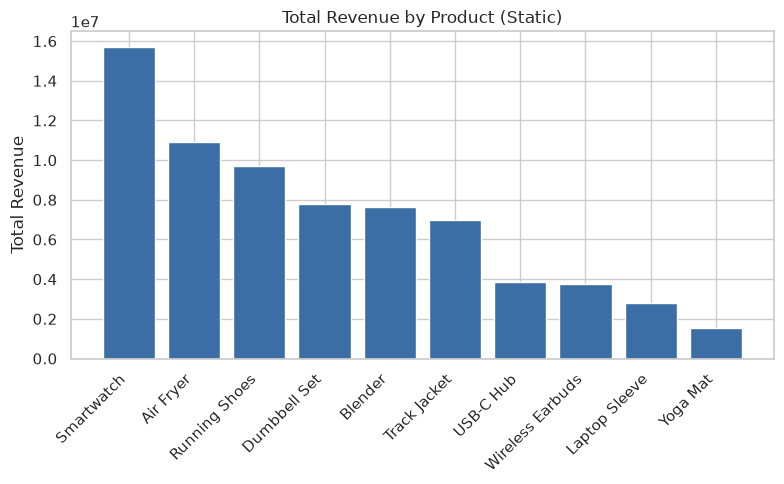

In [3]:
# --- 1a. STATIC chart ---
revenue_by_product = sales_df.groupby("product")["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(revenue_by_product.index, revenue_by_product.values, color="#3b6ea5")
ax.set_xticklabels(revenue_by_product.index, rotation=45, ha="right")
ax.set_ylabel("Total Revenue")
ax.set_title("Total Revenue by Product (Static)")
plt.tight_layout()
plt.show()

In [4]:
# --- 1b. INTERACTIVE chart ---
revenue_by_product_cat = (
    sales_df.groupby(["product", "category"])["revenue"].sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

fig = px.bar(
    revenue_by_product_cat, x="product", y="revenue", hover_data=["category"],
    title="Total Revenue by Product (Interactive)",
)
fig.update_xaxes(categoryorder="total descending")
fig.show()

**Your 1-2 sentence answer:**

The interactive version wins for this request -- the manager specifically asked to
check the exact value of any bar "without squinting at a printed axis," and that's
exactly what plotly's hover tooltip gives: the precise revenue figure plus the
product's category, live, with no follow-up email needed.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [5]:
# create price_slider (FloatRangeSlider) spanning sales_df.unit_price min..max
price_slider = widgets.FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(), max=sales_df.unit_price.max(),
    step=50, description="Price",
)

# create units_slider (IntRangeSlider) spanning sales_df.units_sold min..max
units_slider = widgets.IntRangeSlider(
    value=[int(sales_df.units_sold.min()), int(sales_df.units_sold.max())],
    min=int(sales_df.units_sold.min()), max=int(sales_df.units_sold.max()),
    step=1, description="Units",
)

def dynamic_filter(price_range, units_range):
    # filter sales_df using both ranges
    mask = sales_df.unit_price.between(*price_range) & sales_df.units_sold.between(*units_range)
    filtered = sales_df[mask]

    print(f"{len(filtered)} / {len(sales_df)} rows match")

    # scatter plot: all rows in gray, filtered rows highlighted in color
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sales_df.unit_price, sales_df.units_sold, color="lightgray", s=15, alpha=0.5, label="all")
    ax.scatter(filtered.unit_price, filtered.units_sold, color="#b5432e", s=20, label="matching")
    ax.set_xlabel("Unit Price"); ax.set_ylabel("Units Sold")
    ax.legend()
    plt.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Price', max=4999.0, min=799.0, step…

<function __main__.dynamic_filter(price_range, units_range)>

**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_

`sales_df` today is 1,440 rows. A flat "50x larger" would land at 72,000 rows, still
technically under the ~100,000 guideline -- but "500 stores" specifically (up from 6),
keeping the same 10 products and 24 months, works out to 120,000 rows, which is over
the threshold. Either way I wouldn't want to bet the interface on being just barely
under a soft guideline. At that scale I'd switch to an **aggregated view with
drill-down** (structural zooming) -- render a binned 2D density heatmap of price vs.
units instead of a raw scatter of every point, and let a click drill into a bin's
underlying rows, so the rendering cost stops scaling with the raw row count.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [6]:
store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1: bar chart of store_overview, selected store highlighted, others muted gray
    colors = ["#b5432e" if s == selected_store else "lightgray" for s in store_overview.store_id]
    axes[0].bar(store_overview.store_id, store_overview.revenue, color=colors)
    axes[0].set_title("All Stores (Overview)")
    axes[0].set_ylabel("Total Revenue")

    store_df = sales_df[sales_df.store_id == selected_store]

    # 2: category breakdown pie/bar for selected_store only
    cat_rev = store_df.groupby("category").revenue.sum()
    axes[1].pie(cat_rev.values, labels=cat_rev.index, autopct="%1.0f%%")
    axes[1].set_title(f"{selected_store} Category Breakdown")

    # 3: monthly revenue trend line for selected_store only
    monthly = store_df.groupby("month").revenue.sum()
    axes[2].plot(monthly.index, monthly.values, marker="o", color="#3b6ea5")
    axes[2].set_title(f"{selected_store} Monthly Trend")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

interact(store_coordinated_view,
         selected_store=widgets.Dropdown(options=stores["store_id"].tolist(), description="Store"))

interactive(children=(Dropdown(description='Store', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'), value=…

<function __main__.store_coordinated_view(selected_store)>

**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_

The overview bar chart of all 6 stores is the **context** (it always shows how the
selected store compares to everyone else), and the category pie chart plus the monthly
trend line are the **focus** (the detail view zoomed into just the one selected store).
This is related to brushing but not the same idea: brushing is the *interaction
mechanism* -- picking a store in the dropdown, which recolors and refilters the other
views -- while focus+context is the *design goal* that brushing is being used to
achieve here, keeping the detail visible without ever losing sight of the overview.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [7]:
# --- Part A: find the anomaly ---
anomaly_ranking = (
    sales_df.groupby(["store_id", "product"]).units_sold.agg(["min", "median"])
)
anomaly_ranking["ratio"] = anomaly_ranking["min"] / anomaly_ranking["median"]
anomaly_ranking = anomaly_ranking.sort_values("ratio").head(5)
anomaly_ranking

,,min,median,ratio
store_id,product,,,
S03,Smartwatch,3.9,21.0,0.185714
S05,USB-C Hub,2.0,8.0,0.250000
S01,Track Jacket,3.0,10.0,0.300000
S03,USB-C Hub,5.0,16.5,0.303030
S02,Yoga Mat,3.0,9.5,0.315789


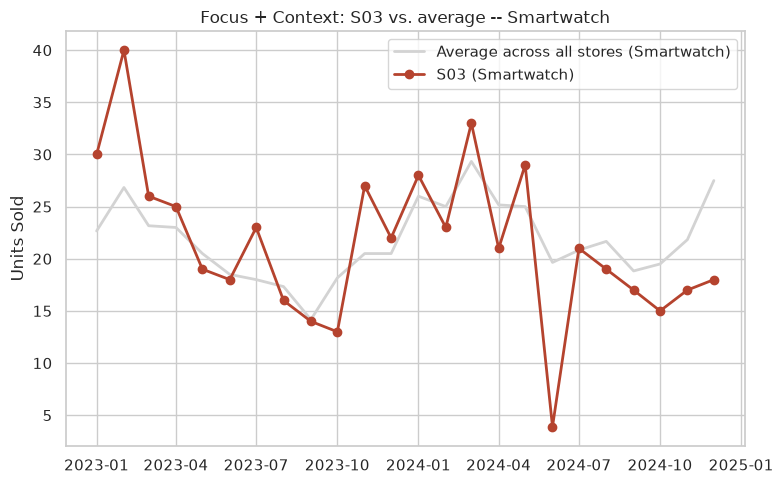

In [8]:
# --- Part B: drill-down with context preserved ---

# 1: overview plotly line chart of units_sold over month, one line per (store_id, product)
#    combination, with hover showing store_id + product (cheap-tier epistemic action)
sales_df["store_product"] = sales_df["store_id"] + " - " + sales_df["product"]
fig_overview = px.line(
    sales_df, x="month", y="units_sold", color="store_product",
    hover_name="store_product", title="All Store x Product Trends (hover to inspect)",
)
fig_overview.update_layout(showlegend=False)  # 60 lines is too many for a legend
fig_overview.show()

# 2: using the (store_id, product) pair identified as the top anomaly in Part A,
#    plot its monthly units_sold trend (focus) together with the average trend for that
#    SAME product across all other stores (context), on one shared chart
anomaly_store, anomaly_product = anomaly_ranking.index[0]

focus = (sales_df[(sales_df.store_id == anomaly_store) & (sales_df["product"] == anomaly_product)]
         .groupby("month").units_sold.mean())
context = (sales_df[sales_df["product"] == anomaly_product]
           .groupby("month").units_sold.mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(context.index, context.values, color="lightgray", lw=2,
        label=f"Average across all stores ({anomaly_product})")
ax.plot(focus.index, focus.values, color="#b5432e", lw=2, marker="o",
        label=f"{anomaly_store} ({anomaly_product})")
ax.legend()
ax.set_title(f"Focus + Context: {anomaly_store} vs. average -- {anomaly_product}")
ax.set_ylabel("Units Sold")
plt.tight_layout()
plt.show()

**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_

I used **hover** (the cheap tier) on the 60-line overview chart to first spot which
line had an obvious dip, then escalated to a **click-to-open panel**-equivalent -- a
separate, more detailed focus+context chart -- to actually investigate it, rather than
jumping straight to a full window replacement. That matches the lecture's design rule:
start with the cheapest tier that can answer the question, and only escalate to a more
expensive tier once the cheap one has actually narrowed things down. Going straight to
a full dedicated window for a candidate that turned out to be nothing would have wasted
the manager's time; starting with hover kept early exploration cheap.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [9]:
product_summary = sales_df.groupby("product").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    avg_rating=("avg_rating", "mean"),
).reset_index()

# sort descending by revenue
product_summary_by_revenue = product_summary.sort_values("revenue", ascending=False).reset_index(drop=True)

# style with .style.bar(...) per numeric column + .set_caption(...)
styled_by_revenue = (
    product_summary_by_revenue.style
    .bar(subset=["revenue"], color="#3b6ea5")
    .bar(subset=["profit"], color="#b5432e")
    .bar(subset=["avg_rating"], color="#5aa469")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Product Performance -- sorted by Revenue")
)
styled_by_revenue

,product,revenue,profit,avg_rating
0,Smartwatch,"15,706,358","3,881,507",4.09
1,Air Fryer,"10,901,274","2,593,731",4.04
2,Running Shoes,"9,688,731","2,303,075",4.10
3,Dumbbell Set,"7,796,880","1,829,127",4.11
4,Blender,"7,648,773","1,860,309",4.04
5,Track Jacket,"6,992,502","1,610,283",4.13
6,USB-C Hub,"3,842,442","907,435",4.09
7,Wireless Earbuds,"3,769,985","890,554",4.09
8,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


In [10]:
# re-sort product_summary by profit descending and re-render the styled table
product_summary_by_profit = product_summary.sort_values("profit", ascending=False).reset_index(drop=True)

styled_by_profit = (
    product_summary_by_profit.style
    .bar(subset=["revenue"], color="#3b6ea5")
    .bar(subset=["profit"], color="#b5432e")
    .bar(subset=["avg_rating"], color="#5aa469")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Product Performance -- sorted by Profit")
)
styled_by_profit

,product,revenue,profit,avg_rating
0,Smartwatch,"15,706,358","3,881,507",4.09
1,Air Fryer,"10,901,274","2,593,731",4.04
2,Running Shoes,"9,688,731","2,303,075",4.10
3,Blender,"7,648,773","1,860,309",4.04
4,Dumbbell Set,"7,796,880","1,829,127",4.11
5,Track Jacket,"6,992,502","1,610,283",4.13
6,USB-C Hub,"3,842,442","907,435",4.09
7,Wireless Earbuds,"3,769,985","890,554",4.09
8,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


**Your observation (revenue-sorted vs profit-sorted top rows):**

The top 3 stay identical either way (Smartwatch, Air Fryer, Running Shoes) -- but
positions 4 and 5 do swap: Dumbbell Set outsells Blender in raw revenue, but Blender
edges it out on total profit. That tells a manager revenue rank isn't the same as
profitability rank -- Blender is quietly more profitable per rupee of sales than
Dumbbell Set, and a report that only ever sorts by revenue would never surface that.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


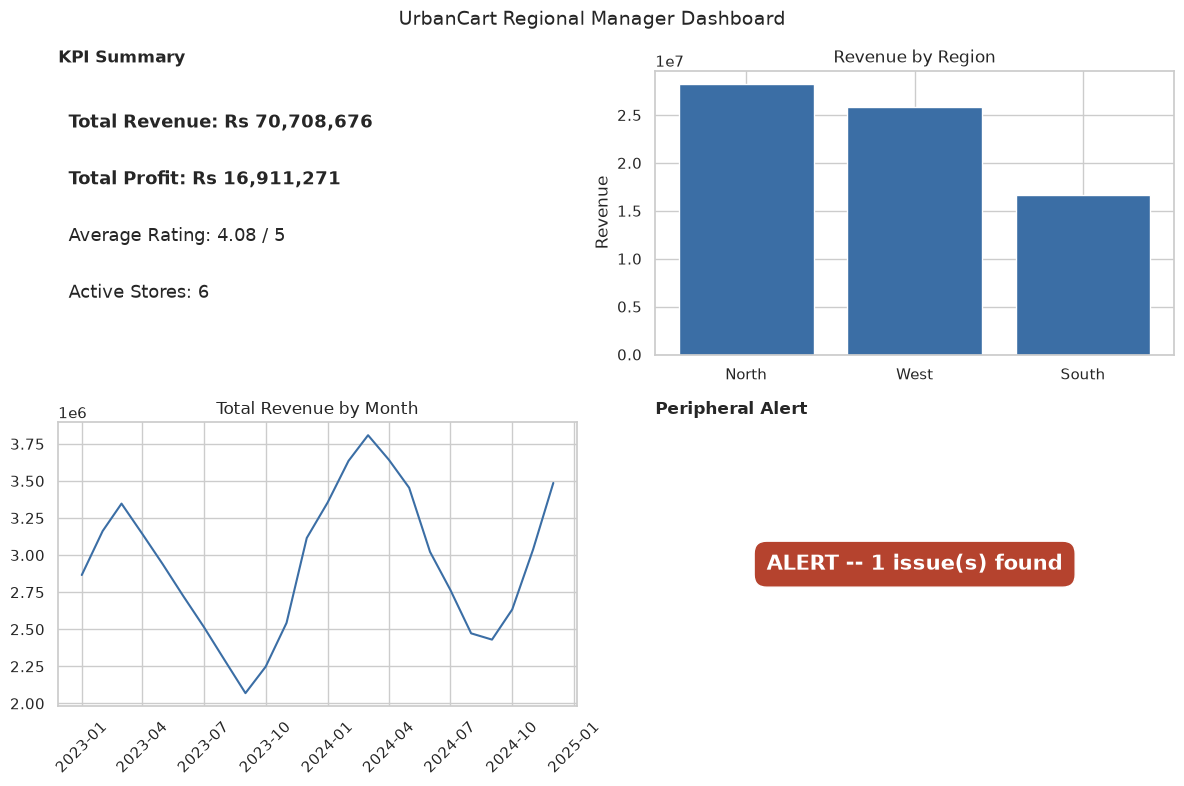

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
ax = axes[0, 0]
ax.axis("off")
total_revenue = sales_df.revenue.sum()
total_profit = sales_df.profit.sum()
avg_rating_overall = sales_df.avg_rating.mean()
n_active_stores = sales_df.store_id.nunique()
ax.text(0.02, 0.8, f"Total Revenue: Rs {total_revenue:,.0f}", fontsize=13, fontweight="bold")
ax.text(0.02, 0.6, f"Total Profit: Rs {total_profit:,.0f}", fontsize=13, fontweight="bold")
ax.text(0.02, 0.4, f"Average Rating: {avg_rating_overall:.2f} / 5", fontsize=13)
ax.text(0.02, 0.2, f"Active Stores: {n_active_stores}", fontsize=13)
ax.set_title("KPI Summary", loc="left", fontweight="bold")

# --- Panel 2: revenue by region (top-right) ---
ax = axes[0, 1]
region_revenue = sales_df.groupby("region").revenue.sum().sort_values(ascending=False)
ax.bar(region_revenue.index, region_revenue.values, color="#3b6ea5")
ax.set_title("Revenue by Region")
ax.set_ylabel("Revenue")

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
ax = axes[1, 0]
monthly_revenue = sales_df.groupby("month").revenue.sum()
ax.plot(monthly_revenue.index, monthly_revenue.values, color="#3b6ea5")
ax.set_title("Total Revenue by Month")
ax.tick_params(axis="x", rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
ax = axes[1, 1]
ax.axis("off")

def find_anomalous_pairs(df, threshold=0.25):
    g = df.groupby(["store_id", "product"]).units_sold.agg(["min", "median"])
    g["ratio"] = g["min"] / g["median"]
    return g[g["ratio"] < threshold]

alerts = find_anomalous_pairs(sales_df)
if len(alerts) > 0:
    ax.text(0.5, 0.5, f"ALERT -- {len(alerts)} issue(s) found", ha="center", va="center",
            fontsize=15, color="white", fontweight="bold",
            bbox=dict(facecolor="#b5432e", boxstyle="round,pad=0.6"))
else:
    ax.text(0.5, 0.5, "OK", ha="center", va="center",
            fontsize=15, color="white", fontweight="bold",
            bbox=dict(facecolor="#3f9142", boxstyle="round,pad=0.6"))
ax.set_title("Peripheral Alert", loc="left", fontweight="bold")

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()

## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here._

1. The **coordinated store views** (Task 3) probably save the most time. Complaint #2
   was literally "comparing stores means flipping between many PDF pages" -- one
   dropdown now replaces however many separate store pages a manager used to click
   through, and the muted-gray overview means they never lose track of how the selected
   store compares to the rest.

2. The **drill-down overview chart** (Task 4, Part B) was the hardest to get right. With
   60 (store, product) lines on one chart, the trade-off was legibility vs. detail: a
   visible legend would be unreadable at that count, but removing it means the only way
   to identify a line is hover -- so I had to trust the "cheap tier first" design rule
   rather than trying to label everything up front.

3. I'd add a **geometric fisheye** to the Task 3 monthly trend line. Right now all 24
   months get equal space, but a manager usually cares most about the last 1-2 months
   with the rest as background context -- a fisheye could expand the most recent months
   for easy reading while compressing the older ones, without dropping them from view
   entirely the way a hard date-range filter would.